In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load data
df = pd.read_csv("../Data/climate_features.csv")

series = df["T2M"].values.reshape(-1,1)

scaler = MinMaxScaler()
series = scaler.fit_transform(series)

# Create sequences
def create_sequences(data, seq_len=30):
    X=[]
    y=[]
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X,y = create_sequences(series)

X=torch.tensor(X).float()
y=torch.tensor(y).float()

# LSTM model
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm=nn.LSTM(1,32,batch_first=True)
        self.fc=nn.Linear(32,1)

    def forward(self,x):
        out,_=self.lstm(x)
        out=self.fc(out[:,-1,:])
        return out

model=LSTMModel()

criterion=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

# Training
for epoch in range(10):
    pred=model(X)
    loss=criterion(pred,y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(epoch,loss.item())

0 0.45473629236221313
1 0.44191089272499084
2 0.42915311455726624
3 0.4164275825023651
4 0.40371644496917725
5 0.3910086452960968
6 0.3782918155193329
7 0.3655503988265991
8 0.3527650535106659
9 0.3399129807949066


In [2]:
losses=[]

for epoch in range(50):

    pred=model(X)
    loss=criterion(pred,y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    print(epoch,loss.item())

0 0.3269689083099365
1 0.31390684843063354
2 0.3007001280784607
3 0.2873212397098541
4 0.27374109625816345
5 0.2599279582500458
6 0.24584783613681793
7 0.23146481812000275
8 0.2167430818080902
9 0.20164839923381805
10 0.18615086376667023
11 0.17022794485092163
12 0.15386946499347687
13 0.13708482682704926
14 0.11991506814956665
15 0.10245277732610703
16 0.08487473428249359
17 0.06749289482831955
18 0.05083256959915161
19 0.035744670778512955
20 0.023543063551187515
21 0.01608668826520443
22 0.015483323484659195
23 0.022465277463197708
24 0.03303580731153488
25 0.04021885246038437
26 0.041084174066782
27 0.036943644285202026
28 0.030502455309033394
29 0.02413049340248108
30 0.019236881285905838
31 0.016281472519040108
32 0.015082432888448238
33 0.015164270997047424
34 0.0160065907984972
35 0.017169717699289322
36 0.018333110958337784
37 0.019289473071694374
38 0.01992345042526722
39 0.02018897421658039
40 0.02009030058979988
41 0.019667603075504303
42 0.018986141309142113
43 0.018127800

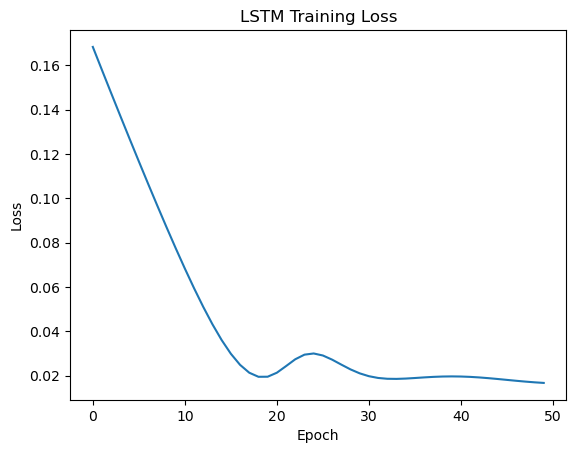

In [3]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

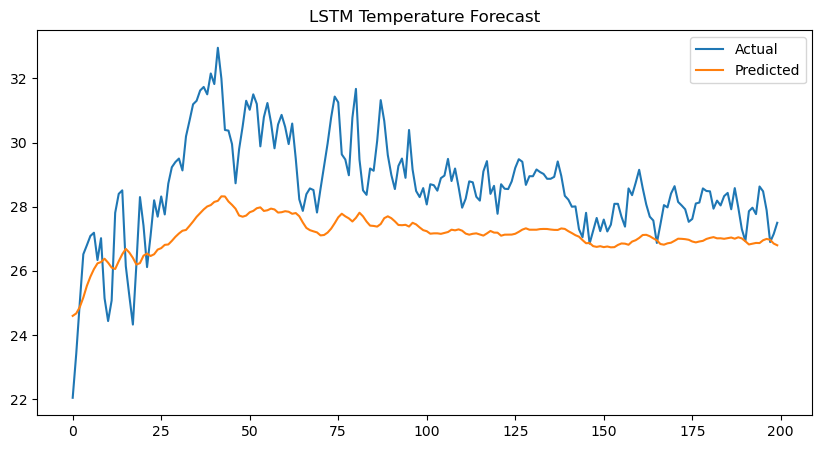

In [4]:
with torch.no_grad():
    preds=model(X).numpy()

preds=scaler.inverse_transform(preds)
actual=scaler.inverse_transform(y.numpy())

plt.figure(figsize=(10,5))

plt.plot(actual[:200],label="Actual")
plt.plot(preds[:200],label="Predicted")

plt.legend()
plt.title("LSTM Temperature Forecast")
plt.show()